# `lp-so-dta` — Ziliaskopoulos's (2000) LP single-destination SO-DTA on CTM cells

**What.** `lp-so-dta` formulates single-destination system-optimal DTA as ONE
linear program by embedding Daganzo's Cell Transmission Model as linear cell-
flow constraints: the CTM's `min(sending, receiving)` Godunov flux equality is
relaxed to its four linear `<=` bounds (conservation stays an equality). Unlike
`merchant-nemhauser`'s exit functions, cells carry FINITE storage, so this LP
can represent queue spillback.

**Why it is in the benchmark.** It is the strongest analytic-DTA anchor in the
benchmark: a certifiable GLOBAL optimum via LP duality, reproducible with
`scipy.optimize.linprog` (no external solver) — no other track in this family
gives up so little to get an exact answer. See the
[model compendium](../../docs/MODELS.md) (Ziliaskopoulos 2000) and
[docs/design/adr-021-lp-so-dta.md](../../docs/design/adr-021-lp-so-dta.md)
(P1).

**Scope.** This notebook solves the LP on two built-in anchors — a control-
free corridor and a diverge with a tiny-storage bottleneck cell (the
spillback effect `merchant-nemhauser`'s exit functions cannot represent) —
and certifies both.

**Canon.** `[ziliaskopoulos2000linear]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below is recomputed live by the P1 `CellSODTAEvaluator` from
the emitted occupancy/flow arrays alone — conservation (with exogenous demand
and the absorbing sink), the four CTM bound families, the storage envelope, and
a weak-duality backstop against the harness's own freshly-solved LP optimum
`Z*`. The solver's self-reported objective is never trusted
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `lp-so-dta` is a core model: a plain `pip install -e .` suffices — no
# optional extra, so no guard cell. The inline backend is Agg-based (headless
# CI renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it
# silently suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    CellSODTAEvaluator,
    solve_cell_so_dta,
    zil_corridor_scenario,
    zil_diverge_spillback_scenario,
)

## Anchor A: a control-free corridor

`R -> A -> B(Q=1, N=2) -> S`, 6 vehicles queued at the source. The LP has no
diverge to control (a single path) — no decision, just the physics.
`CellSODTAScenario` is frozen and content-hashed (P2).

In [2]:
scenario_a = zil_corridor_scenario()
print(f"scenario      : {scenario_a.name}")
print(f"content hash  : {scenario_a.content_hash()[:16]}…")
print(f"cells={scenario_a.n_cells}  sink={scenario_a.sink}  periods={scenario_a.n_periods}")
print(f"capacity={scenario_a.capacity}  storage={scenario_a.storage}")
print(f"initial occupancy at source : {scenario_a.initial_occupancy[0]}")

scenario      : zil-corridor
content hash  : 80ca151d03f194f2…
cells=4  sink=3  periods=10
capacity=[inf 10.  1. inf]  storage=[inf 20.  2. inf]
initial occupancy at source : 6.0


## Solve + certify (Anchor A)

No `Budget`/`RngBundle`/`Trace` — `solve_cell_so_dta` builds the canonical LP
(`cell_canonical_lp`) and solves it with HiGHS to global optimality, emitting a
`CellTrajectory`. `CellSODTAEvaluator` independently re-solves the LP and
certifies feasibility + optimality by pure arithmetic.

In [3]:
trajectory_a = solve_cell_so_dta(scenario_a)
evaluator_a = CellSODTAEvaluator(scenario_a)
metrics_a = evaluator_a.certify(trajectory_a)
print(f"feasible           : {metrics_a['feasible']:.0f}")
print(f"so_optimality_gap   : {metrics_a['so_optimality_gap']:.3e}")
print(f"total_cost          : {metrics_a['total_cost']:.4f}")
print(f"holding_max         : {metrics_a['holding_max']:.4f}  (Tier-B diagnostic, not an error)")
print(f"dual_gap            : {metrics_a['dual_gap']:.3e}")
assert metrics_a["feasible"] == 1.0
assert metrics_a["so_optimality_gap"] < 1e-6
assert np.isclose(metrics_a["total_cost"], 33.0, atol=1e-6)

feasible           : 1
so_optimality_gap   : 0.000e+00
total_cost          : 33.0000
holding_max         : 1.0000  (Tier-B diagnostic, not an error)
dual_gap            : 0.000e+00


## Anchor B: a finite-storage effect exit functions cannot represent

`R -> A -> {B(Q=1, N=1, tiny storage), C -> D(Q=2 each)} -> S`: 6 vehicles at
`R` face a diverge between a short route through a ONE-vehicle-storage
bottleneck cell `B` and a longer route `C -> D`. Certified below: `B` sits
jam-full at `t=2` in the optimum (the spillback pair lemma binds).

In [4]:
scenario_b = zil_diverge_spillback_scenario()
trajectory_b = solve_cell_so_dta(scenario_b)
evaluator_b = CellSODTAEvaluator(scenario_b)
metrics_b = evaluator_b.certify(trajectory_b)
print(f"feasible            : {metrics_b['feasible']:.0f}")
print(f"so_optimality_gap    : {metrics_b['so_optimality_gap']:.3e}")
print(f"total_cost           : {metrics_b['total_cost']:.4f}")
print(f"holding_max          : {metrics_b['holding_max']:.4f}")
assert metrics_b["feasible"] == 1.0
assert metrics_b["so_optimality_gap"] < 1e-6
assert np.isclose(metrics_b["total_cost"], 26.0, atol=1e-6)
# Cell B (index 2) is jam-full (storage 1) at t=2 in every optimum.
b_occ_at_2 = trajectory_b.occupancies[2, 2]
print(f"cell B occupancy at t=2 : {b_occ_at_2:.4f}  (storage cap: {scenario_b.storage[2]})")
assert np.isclose(b_occ_at_2, scenario_b.storage[2], atol=1e-6)

# The distinctive point: relaxing B's storage from 1 to 2 strictly LOWERS the
# optimum -- a genuine finite-storage effect, recomputed here by rebuilding the
# scenario with N_B=2 and re-solving, not quoted.
from dataclasses import replace
relaxed_storage = list(scenario_b.storage)
relaxed_storage[2] = 2.0
relaxed = replace(scenario_b, name="zil-diverge-relaxed-storage", storage=relaxed_storage)
relaxed_traj = solve_cell_so_dta(relaxed)
relaxed_metrics = CellSODTAEvaluator(relaxed).certify(relaxed_traj)
print(f"relaxed (N_B=2) total_cost : {relaxed_metrics['total_cost']:.4f}")
assert relaxed_metrics["feasible"] == 1.0
assert np.isclose(relaxed_metrics["total_cost"], 25.0, atol=1e-6)
assert relaxed_metrics["total_cost"] < metrics_b["total_cost"]
print("finite storage on cell B strictly costs 1 extra veh-interval (26 vs 25) —")
print("an effect the exit-function merchant-nemhauser model cannot represent.")

feasible            : 1
so_optimality_gap    : 0.000e+00
total_cost           : 26.0000
holding_max          : 0.0000
cell B occupancy at t=2 : 1.0000  (storage cap: 1.0)
relaxed (N_B=2) total_cost : 25.0000
finite storage on cell B strictly costs 1 extra veh-interval (26 vs 25) —
an effect the exit-function merchant-nemhauser model cannot represent.


## Visualize

`tabench.viz` is a road-network flow visualizer; the LP artifact is a per-cell
OCCUPANCY trajectory, not a static link-flow vector, so this notebook plots
the certified occupancy trajectories directly.

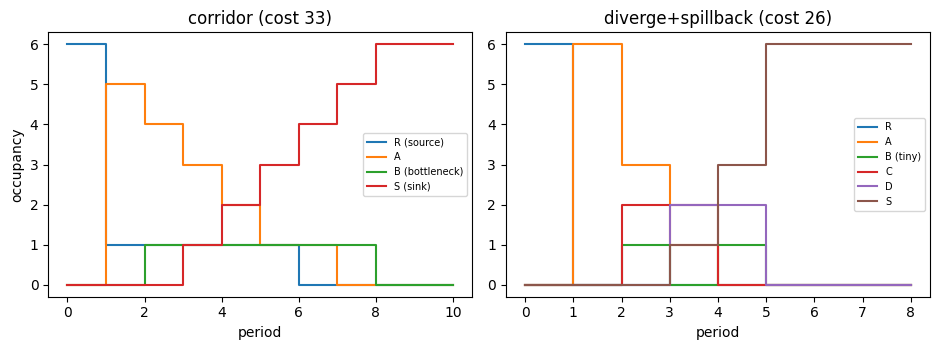

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
labels_a = ["R (source)", "A", "B (bottleneck)", "S (sink)"]
for i, label in enumerate(labels_a):
    axes[0].step(range(trajectory_a.occupancies.shape[0]), trajectory_a.occupancies[:, i],
                 where="post", label=label)
axes[0].set_title(f"corridor (cost {metrics_a['total_cost']:.0f})")
axes[0].set_xlabel("period")
axes[0].set_ylabel("occupancy")
axes[0].legend(fontsize=7)

labels_b = ["R", "A", "B (tiny)", "C", "D", "S"]
for i, label in enumerate(labels_b):
    axes[1].step(range(trajectory_b.occupancies.shape[0]), trajectory_b.occupancies[:, i],
                 where="post", label=label)
axes[1].set_title(f"diverge+spillback (cost {metrics_b['total_cost']:.0f})")
axes[1].set_xlabel("period")
axes[1].legend(fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)


## Takeaways & pointers

- **Certified, not self-reported.** Both anchors' costs came from
  `CellSODTAEvaluator`, which re-solves the LP itself and cross-checks the
  dual certificate — never the solver's own objective claim.
- **Finite storage is the point.** `merchant-nemhauser`'s exit functions have
  no analogue of `N_B`; the 26-vs-25 gap recomputed above is real physics this
  LP can represent that the exit-function model cannot.
- **Where next.** the exit-function twin
  [`merchant-nemhauser`](01-merchant-nemhauser.ipynb) (no finite storage); the
  CTM cell scheme this LP relaxes [`ctm`](../05-dnl/01-ctm.ipynb); the lineage
  in the [model compendium](../../docs/MODELS.md).